# **CNN (Convolutional Neural Network) Training**

### **Introduction to CNN**

CNN (Convolutional Neural Network) image classification ke liye ek powerful deep learning architecture hai. CNN images mein patterns, edges, aur features ko automatically detect karne ke liye specialized layers use karti hai:

- **Conv2D Layers**: Images mein features detect karti hain (edges, shapes, textures)
- **MaxPooling2D Layers**: Spatial dimensions ko reduce karti hain aur computation ko optimize karti hain
- **Flatten Layer**: 2D feature maps ko 1D vector mein convert karti hai
- **Dense Layers**: Final classification ke liye

**MNIST Dataset**: 70,000 grayscale images of handwritten digits (0-9) - 28x28 pixels each



## **Step 1: Import Required Libraries**


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")



c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

TensorFlow version: 2.20.0
Keras version: 3.11.2


## **Step 2: Load and Explore the Dataset**


In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("\nPixel value range:", x_train.min(), "to", x_train.max())
print("Number of classes:", len(np.unique(y_train)))



Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range: 0 to 255
Number of classes: 10


ek photo---3600

ann

<!-- 
x1w1--0.3+b=0.7
x2w2--0.6+b=0.9


x5w2+b=0.9 -->


frame

(3,3),(5,5)


maxpooling,averagepooling

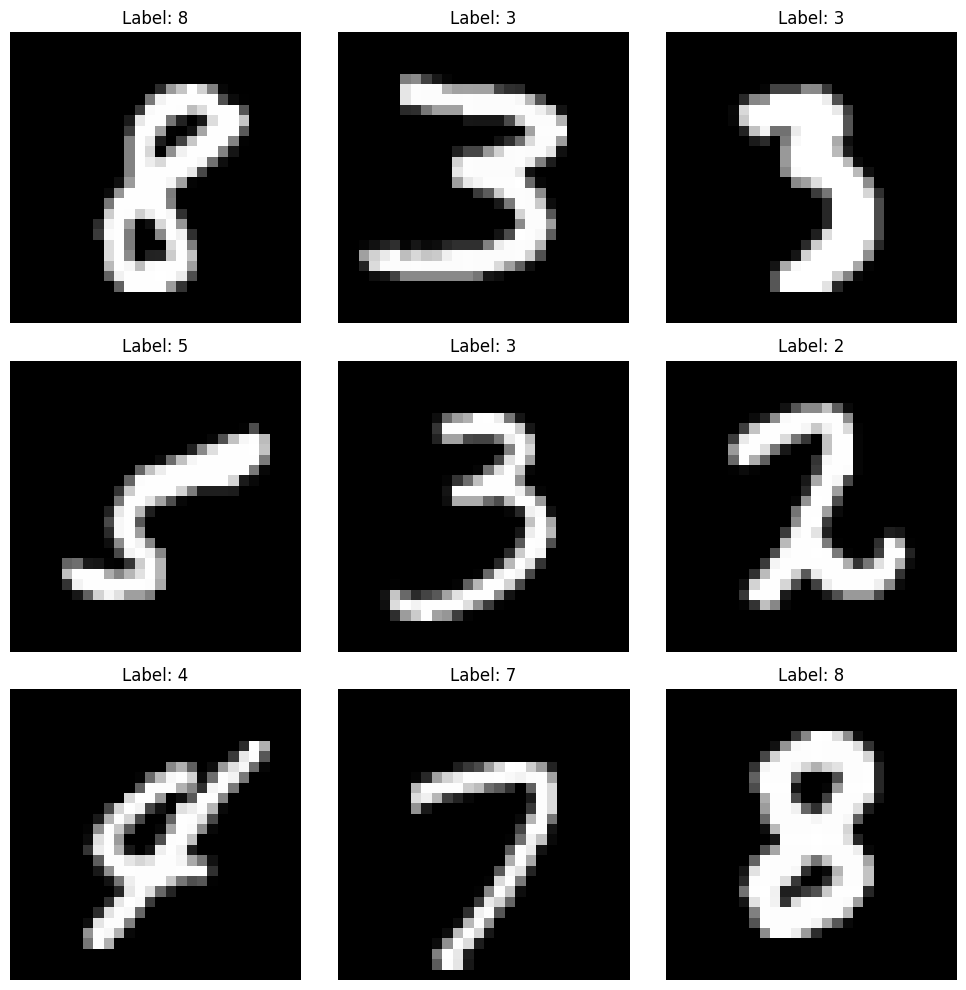

In [3]:
# Visualize some sample images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.ravel()

for i in range(9):
    idx = np.random.randint(0, len(x_train))
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(f"Label: {y_train[idx]}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()



## **Step 3: Data Preprocessing**


In [4]:
# Reshape data for CNN (add channel dimension)
# CNN expects input shape: (batch_size, height, width, channels)
# MNIST is grayscale, so channels = 1
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print("After reshaping:")
print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)



After reshaping:
Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [5]:
# Normalize pixel values to range [0, 1]
# Convert from uint8 (0-255) to float32 (0.0-1.0)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("After normalization:")
print("Min value:", x_train.min())
print("Max value:", x_train.max())
print("Data type:", x_train.dtype)



After normalization:
Min value: 0.0
Max value: 1.0
Data type: float32


In [6]:
# One-hot encode the labels
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("After one-hot encoding:")
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)
print("\nExample label (first sample):", y_train[0])



After one-hot encoding:
Training labels shape: (60000, 10)
Test labels shape: (10000, 10)

Example label (first sample): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## **Step 4: Build CNN Model Architecture**


In [ ]:
# Create Sequential model
model = keras.Sequential([
    
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv2d_1'),
    layers.MaxPooling2D((2, 2), name='maxpool_1'),
    layers.BatchNormalization(name='batchnorm_1'),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', name='conv2d_2'),
    layers.MaxPooling2D((2, 2), name='maxpool_2'),
    layers.BatchNormalization(name='batchnorm_2'),
    
    # Third Convolutional Block (optional - for deeper network)
    layers.Conv2D(128, (3, 3), activation='relu', name='conv2d_3'),
    layers.MaxPooling2D((2, 2), name='maxpool_3'),
    layers.BatchNormalization(name='batchnorm_3'),
    
    # Flatten layer - converts 2D feature maps to 1D vector
    layers.Flatten(name='flatten'),
    
    # Dense (Fully Connected) Layers
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dropout(0.5, name='dropout_1'),  # Dropout for regularization
    
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.Dropout(0.3, name='dropout_2'),
    
    # Output layer - 10 classes (digits 0-9)
    layers.Dense(num_classes, activation='softmax', name='output')
])

# Display model architecture
model.summary()



c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 8)        │         4,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 1, 1, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 1, 1, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,906 (132.45 KB)

 Trainable params: 33,698 (131.63 KB)

 Non-trainable params: 208 (832.00 B)

### **Model Architecture Explanation:**

1. **Conv2D(32, 3x3)**: 32 filters, 3x3 kernel size - detects basic features like edges
2. **MaxPooling2D(2x2)**: Reduces spatial dimensions by half, reduces parameters
3. **BatchNormalization**: Stabilizes training, speeds up convergence
4. **Conv2D(64, 3x3)**: 64 filters - detects more complex patterns
5. **Conv2D(128, 3x3)**: 128 filters - detects even more complex features
6. **Flatten**: Converts 2D feature maps to 1D for dense layers
7. **Dense(128)**: Fully connected layer with 128 neurons
8. **Dropout(0.5)**: Prevents overfitting by randomly setting 50% neurons to 0 during training
9. **Dense(10, softmax)**: Output layer with 10 neurons (one for each digit class)



## **Step 5: Compile the Model**


In [8]:
# Compile the model
model.compile(
    optimizer='adam',  # Adaptive learning rate optimizer
    loss='categorical_crossentropy',  # For multi-class classification
    metrics=['accuracy']  # Track accuracy during training
)

print("Model compiled successfully!")
print("\nOptimizer: Adam")
print("Loss function: categorical_crossentropy")
print("Metrics: accuracy")



Model compiled successfully!

Optimizer: Adam
Loss function: categorical_crossentropy
Metrics: accuracy


## **Step 6: Train the Model**


In [9]:
# Define training parameters
batch_size = 128
epochs = 10

print(f"Starting training...")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_test)}")



Starting training...
Batch size: 128
Epochs: 10
Training samples: 60000
Validation samples: 10000


In [10]:
# Train the model
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test),
    shuffle=True  # Shuffle training data each epoch
)

print("\nTraining completed!")



Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.8480 - loss: 0.5068 - val_accuracy: 0.6733 - val_loss: 0.9895
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9578 - loss: 0.1562 - val_accuracy: 0.9721 - val_loss: 0.0969
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9678 - loss: 0.1165 - val_accuracy: 0.9733 - val_loss: 0.0921
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9729 - loss: 0.1007 - val_accuracy: 0.9786 - val_loss: 0.0801
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9772 - loss: 0.0842 - val_accuracy: 0.9777 - val_loss: 0.0828
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9797 - loss: 0.0749 - val_accuracy: 0.9799 - val_loss: 0.0726
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9816 - loss: 0.0665 - val_accuracy: 0.9786 - val_loss: 0.0775
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9828 - loss: 0.0619 - 

## **Step 7: Evaluate the Model**


In [11]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 50)



MODEL EVALUATION RESULTS
Test Loss: 0.0725
Test Accuracy: 0.9806 (98.06%)


## **Step 8: Visualize Training History**


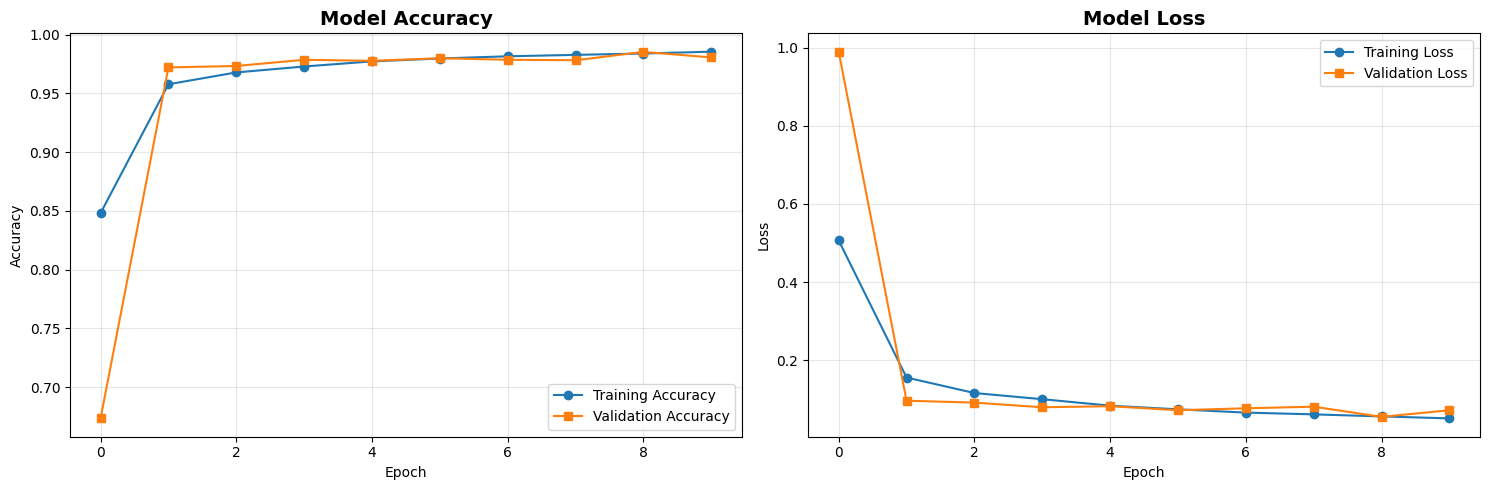

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## **Step 9: Make Predictions**


In [13]:
# Make predictions on test set
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(f"Predictions shape: {y_pred.shape}")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"First 10 true labels: {y_true[:10]}")



Predictions shape: (10000,)

First 10 predictions: [7 2 1 0 4 1 4 9 5 9]
First 10 true labels: [7 2 1 0 4 1 4 9 5 9]


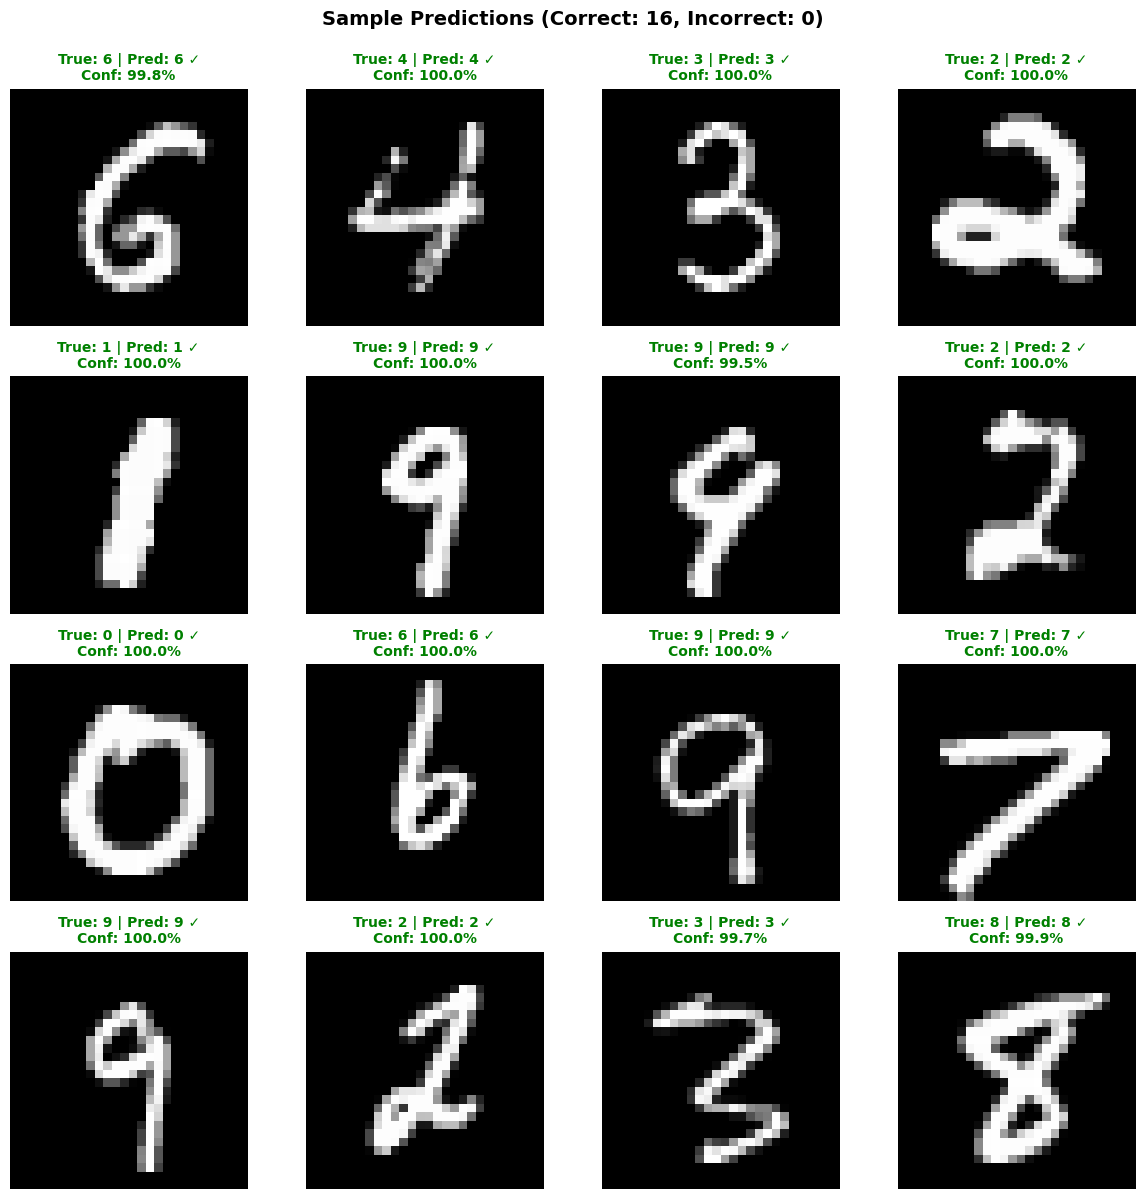

In [14]:
# Visualize predictions
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

correct = 0
incorrect = 0

for i in range(16):
    idx = np.random.randint(0, len(x_test))
    
    axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    
    pred_label = y_pred[idx]
    true_label = y_true[idx]
    confidence = y_pred_probs[idx][pred_label] * 100
    
    if pred_label == true_label:
        color = 'green'
        correct += 1
        status = '✓'
    else:
        color = 'red'
        incorrect += 1
        status = '✗'
    
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label} {status}\nConf: {confidence:.1f}%", 
                     color=color, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Sample Predictions (Correct: {correct}, Incorrect: {incorrect})", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



## **Step 10: Classification Report and Confusion Matrix**


In [15]:
# Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, digits=4))
print("=" * 60)



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9866    0.9796    0.9831       980
           1     0.9886    0.9930    0.9908      1135
           2     0.9717    0.9661    0.9689      1032
           3     0.9682    0.9941    0.9809      1010
           4     0.9847    0.9837    0.9842       982
           5     0.9821    0.9821    0.9821       892
           6     0.9885    0.9875    0.9880       958
           7     0.9636    0.9776    0.9705      1028
           8     0.9947    0.9723    0.9834       974
           9     0.9790    0.9693    0.9741      1009

    accuracy                         0.9806     10000
   macro avg     0.9808    0.9805    0.9806     10000
weighted avg     0.9807    0.9806    0.9806     10000



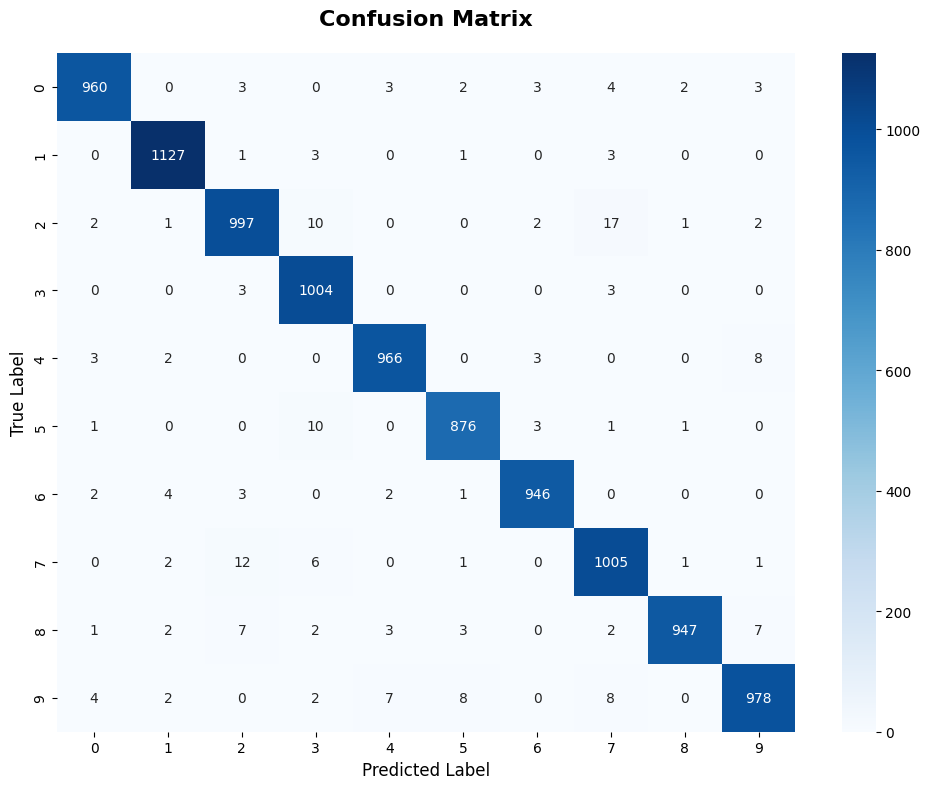

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()



## **Step 11: Save the Model**


In [17]:
# Save the trained model
model_path = 'cnn_mnist_model.keras'
model.save(model_path)

print(f"Model saved successfully to: {model_path}")
print(f"\nModel can be loaded later using:")
print(f"model = keras.models.load_model('{model_path}')")

 

Model saved successfully to: cnn_mnist_model.keras

Model can be loaded later using:
model = keras.models.load_model('cnn_mnist_model.keras')


## **Step 12: Test on Custom Predictions**


In [18]:
# Test on random samples
def predict_digit(image):
    """Predict a single digit from image"""
    # Ensure correct shape
    if len(image.shape) == 2:
        image = image.reshape(1, 28, 28, 1)
    
    # Normalize
    image = image.astype('float32') / 255.0
    
    # Predict
    prediction = model.predict(image, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class] * 100
    
    return predicted_class, confidence, prediction[0]

# Test on a few random samples
print("Testing on random samples:\n")
for i in range(5):
    idx = np.random.randint(0, len(x_test))
    test_image = x_test[idx]
    true_label = y_true[idx]
    
    pred_class, confidence, all_probs = predict_digit(test_image)
    
    print(f"Sample {i+1}:")
    print(f"  True Label: {true_label}")
    print(f"  Predicted: {pred_class}")
    print(f"  Confidence: {confidence:.2f}%")
    print(f"  Status: {'✓ Correct' if pred_class == true_label else '✗ Incorrect'}")
    print()



Testing on random samples:



ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

## **Summary**

### **What we accomplished:**

1. ✅ Loaded and explored MNIST dataset
2. ✅ Preprocessed data (reshaping, normalization, one-hot encoding)
3. ✅ Built a CNN architecture with:
   - 3 Convolutional blocks (32, 64, 128 filters)
   - MaxPooling layers for dimensionality reduction
   - BatchNormalization for stable training
   - Dense layers for classification
   - Dropout for regularization
4. ✅ Compiled model with Adam optimizer
5. ✅ Trained model on 60,000 training images
6. ✅ Evaluated model on 10,000 test images
7. ✅ Visualized training history and predictions
8. ✅ Generated classification report and confusion matrix
9. ✅ Saved the trained model

### **Key CNN Concepts:**
- **Convolution**: Feature detection from images
- **Pooling**: Spatial dimension reduction
- **Flattening**: Converting 2D to 1D for dense layers
- **Dropout**: Preventing overfitting
- **Batch Normalization**: Faster and more stable training

### **Next Steps (Optional Improvements):**
- Try different architectures (more/fewer layers)
- Experiment with different filter sizes
- Add data augmentation (rotation, shifting, zooming)
- Try different optimizers (RMSprop, SGD)
- Adjust learning rate
- Try different activation functions

